In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix, RocCurveDisplay)
from sklearn.model_selection import GridSearchCV

plt.style.use('seaborn-v0_8-darkgrid')

# Load data
X_train = pd.read_csv("../data/X_train.csv", index_col=0, parse_dates=True)
X_test  = pd.read_csv("../data/X_test.csv",  index_col=0, parse_dates=True)
y_train = pd.read_csv("../data/y_train.csv", index_col=0, parse_dates=True).squeeze()
y_test  = pd.read_csv("../data/y_test.csv",  index_col=0, parse_dates=True).squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (957, 7)
X_test : (240, 7)


In [3]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(f"Accuracy : {accuracy_score(y_test, lr_preds):.4f}")
print(f"F1 Score : {f1_score(y_test, lr_preds):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, lr_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds))

=== Logistic Regression ===
Accuracy : 0.5208
F1 Score : 0.4221
ROC-AUC  : 0.5362

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.69      0.59       120
           1       0.53      0.35      0.42       120

    accuracy                           0.52       240
   macro avg       0.52      0.52      0.51       240
weighted avg       0.52      0.52      0.51       240



In [4]:
print("Running GridSearchCV for Random Forest... (may take 1-2 mins)")

rf_params = {
    'n_estimators': [100, 200],
    'max_depth'   : [3, 5, 10],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print(f"\nBest Params : {rf_grid.best_params_}")
print(f"Best ROC-AUC: {rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_
rf_preds = rf_best.predict(X_test)
rf_proba = rf_best.predict_proba(X_test)[:, 1]

print("\n=== Random Forest (Tuned) ===")
print(f"Accuracy : {accuracy_score(y_test, rf_preds):.4f}")
print(f"F1 Score : {f1_score(y_test, rf_preds):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, rf_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds))

Running GridSearchCV for Random Forest... (may take 1-2 mins)
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Params : {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best ROC-AUC: 0.4195

=== Random Forest (Tuned) ===
Accuracy : 0.5375
F1 Score : 0.5394
ROC-AUC  : 0.5445

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.53      0.54       120
           1       0.54      0.54      0.54       120

    accuracy                           0.54       240
   macro avg       0.54      0.54      0.54       240
weighted avg       0.54      0.54      0.54       240



In [5]:
print("Running GridSearchCV for XGBoost... (may take 1-2 mins)")

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth'   : [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample'   : [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    xgb_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print(f"\nBest Params : {xgb_grid.best_params_}")
print(f"Best ROC-AUC: {xgb_grid.best_score_:.4f}")

xgb_best = xgb_grid.best_estimator_
xgb_preds = xgb_best.predict(X_test)
xgb_proba = xgb_best.predict_proba(X_test)[:, 1]

print("\n=== XGBoost (Tuned) ===")
print(f"Accuracy : {accuracy_score(y_test, xgb_preds):.4f}")
print(f"F1 Score : {f1_score(y_test, xgb_preds):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, xgb_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds))

Running GridSearchCV for XGBoost... (may take 1-2 mins)
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Params : {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
Best ROC-AUC: 0.4445

=== XGBoost (Tuned) ===
Accuracy : 0.5625
F1 Score : 0.4878
ROC-AUC  : 0.5721

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.71      0.62       120
           1       0.59      0.42      0.49       120

    accuracy                           0.56       240
   macro avg       0.57      0.56      0.55       240
weighted avg       0.57      0.56      0.55       240



In [6]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest (Tuned)', 'XGBoost (Tuned)'],
    'Accuracy': [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds)
    ],
    'F1 Score': [
        f1_score(y_test, lr_preds),
        f1_score(y_test, rf_preds),
        f1_score(y_test, xgb_preds)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, xgb_proba)
    ]
}).round(4)

print("=== Model Comparison ===")
print(results.to_string(index=False))

=== Model Comparison ===
                Model  Accuracy  F1 Score  ROC-AUC
  Logistic Regression    0.5208    0.4221   0.5362
Random Forest (Tuned)    0.5375    0.5394   0.5445
      XGBoost (Tuned)    0.5625    0.4878   0.5721


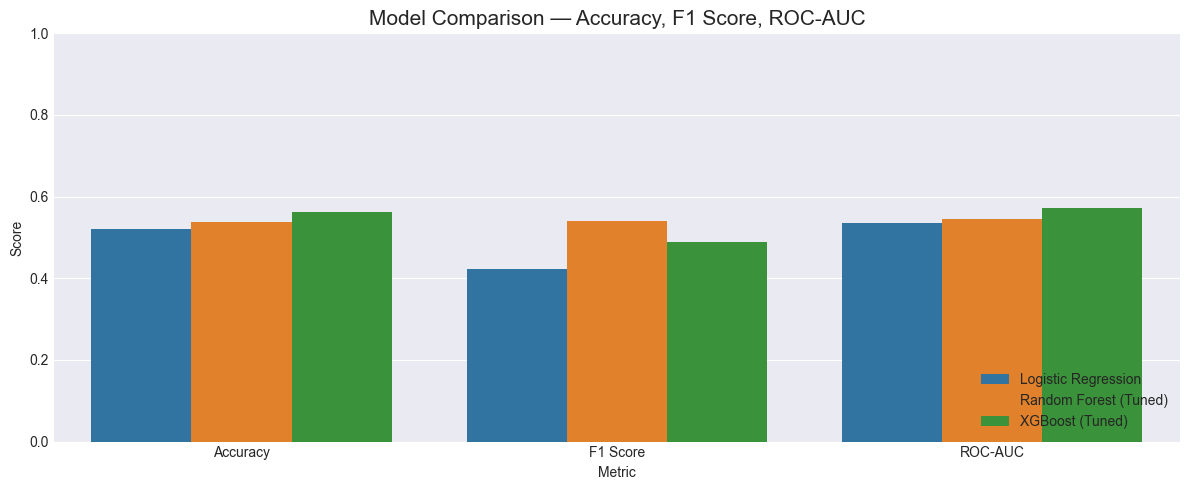

In [7]:
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 5))
sns.barplot(data=results_melted, x='Metric', y='Score', hue='Model')
plt.title('Model Comparison — Accuracy, F1 Score, ROC-AUC', fontsize=15)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150)
plt.show()

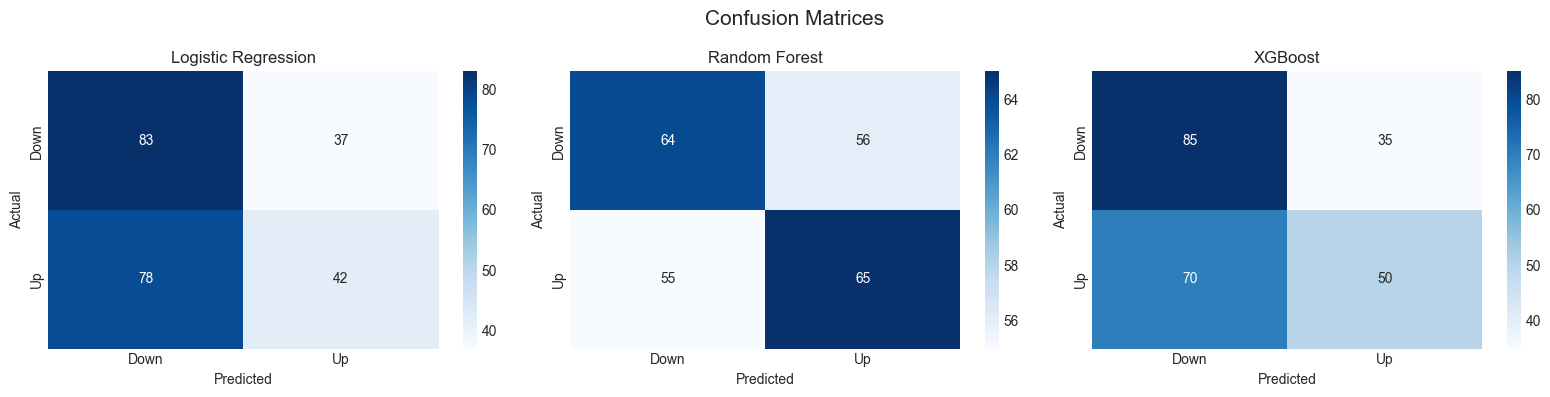

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

models_info = [
    ('Logistic Regression', lr_preds),
    ('Random Forest',       rf_preds),
    ('XGBoost',             xgb_preds)
]

for ax, (name, preds) in zip(axes, models_info):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Down', 'Up'],
                yticklabels=['Down', 'Up'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=15)
plt.tight_layout()
plt.savefig('../data/confusion_matrices.png', dpi=150)
plt.show()

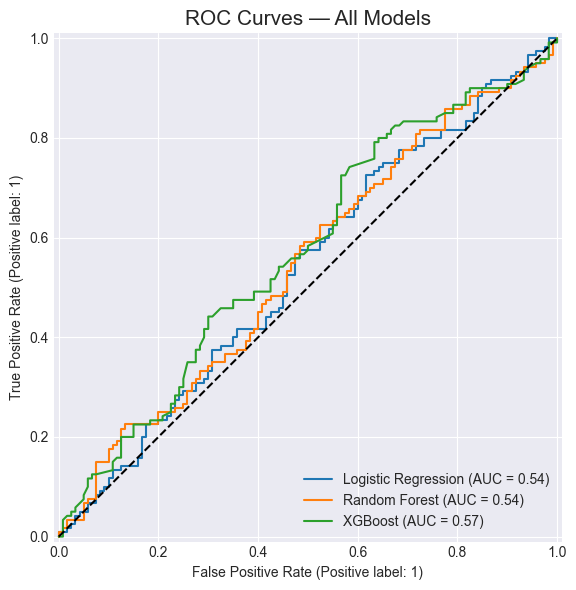

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, lr_proba,  name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_proba,  name='Random Forest',       ax=ax)
RocCurveDisplay.from_predictions(y_test, xgb_proba, name='XGBoost',             ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
ax.set_title('ROC Curves — All Models', fontsize=15)
plt.tight_layout()
plt.savefig('../data/roc_curves.png', dpi=150)
plt.show()

C:\Users\agraw\AppData\Local\Temp\ipykernel_12340\1034387231.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


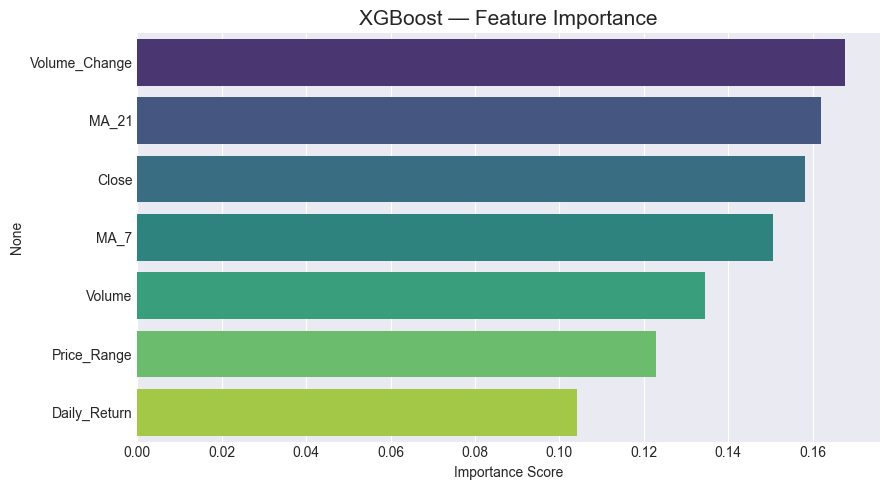

In [10]:
# XGBoost feature importance
feat_imp = pd.Series(xgb_best.feature_importances_,
                     index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('XGBoost — Feature Importance', fontsize=15)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()

In [11]:
os.makedirs("../models", exist_ok=True)

# Save all 3 models
joblib.dump(lr,       "../models/logistic_regression.pkl")
joblib.dump(rf_best,  "../models/random_forest.pkl")
joblib.dump(xgb_best, "../models/xgboost.pkl")

print("All models saved ✅")

# Identify and save best model separately based on ROC-AUC
best_idx   = results['ROC-AUC'].idxmax()
best_name  = results.loc[best_idx, 'Model']
print(f"\nBest Model: {best_name}")

# Save best model reference for Flask API
best_models = {'Logistic Regression': lr, 
               'Random Forest (Tuned)': rf_best, 
               'XGBoost (Tuned)': xgb_best}

joblib.dump(best_models[best_name], "../models/best_model.pkl")
print(f"Best model saved as best_model.pkl ✅")

All models saved ✅

Best Model: XGBoost (Tuned)
Best model saved as best_model.pkl ✅
